<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/Notebook_1_Click/Notebook06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print('Libraries imported successfully')

Libraries imported successfully


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System.csv


In [5]:
df = pd.read_csv('Conditional_Base_Monitoring in Marine_System.csv')

df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df = df.drop_duplicates()

print('Shape:', df.shape)

Shape: (11936, 18)


In [6]:
target_column = 'GT Compressor decay state coefficient'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

Train: 9548 | Test: 2388


In [7]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('R2:  ', round(r2,   6))
print('MAE: ', round(mae,  6))
print('RMSE:', round(rmse, 6))

R2:   0.998192
MAE:  0.000399
RMSE: 0.000633


                                          Feature  Importance
9   GT Compressor outlet air temperature (T2) [C]    0.298905
10           HP Turbine exit pressure (P48) [bar]    0.184980
13           GT exhaust gas pressure (Pexh) [bar]    0.147070
2      Gas Turbine (GT) shaft torque (GTT) [kN m]    0.146884
4   Gas Generator rate of revolutions (GGn) [rpm]    0.132371
3              GT rate of revolutions (GTn) [rpm]    0.032629
16             GT Turbine decay state coefficient    0.016715
14             Turbine Injecton Control (TIC) [%]    0.010331
6                 Port Propeller Torque (Tp) [kN]    0.006546
5            Starboard Propeller Torque (Ts) [kN]    0.006455


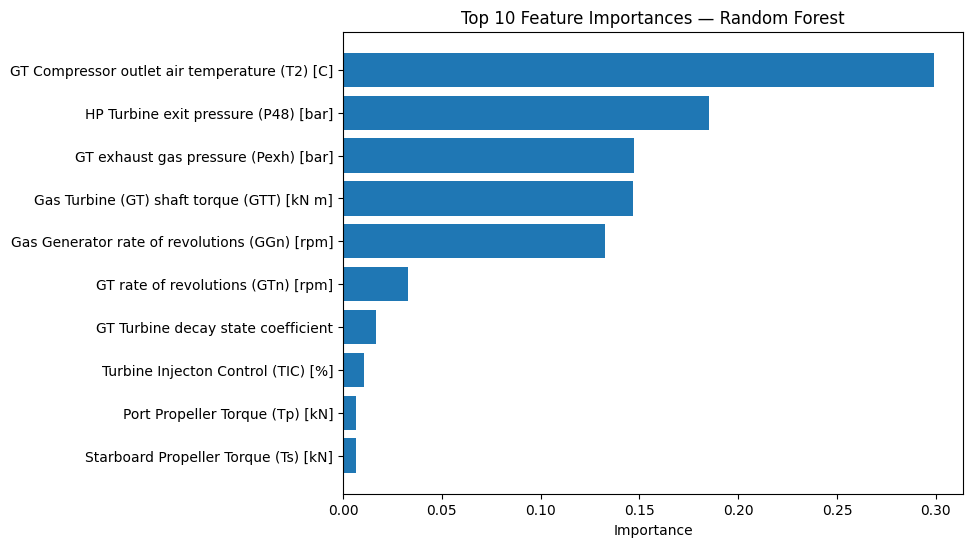

In [8]:
importances = rf_model.feature_importances_
features    = X.columns

importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

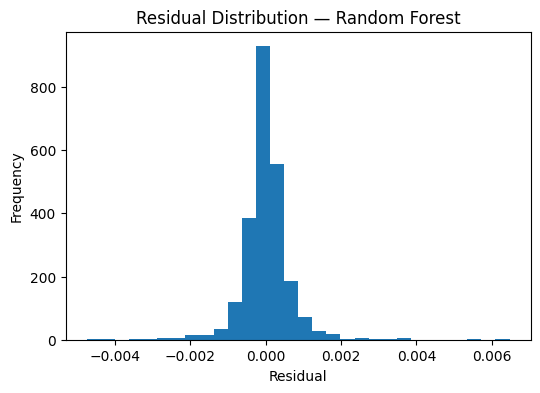

In [9]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title('Residual Distribution — Random Forest')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

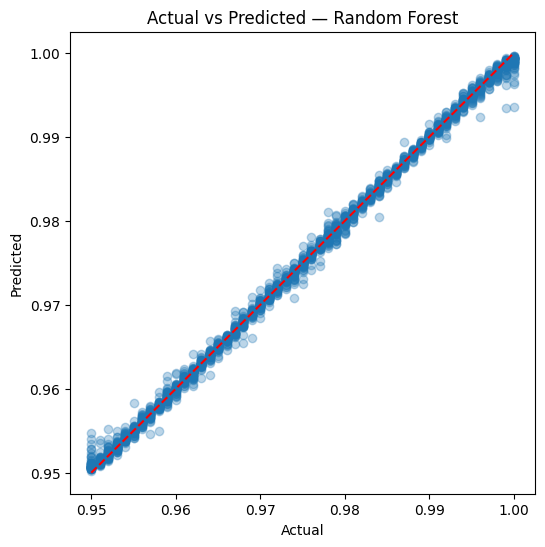

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted — Random Forest')
plt.show()